In [9]:
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_abnb = pd.read_csv('./data/ABNB_stock.csv')
df_abnb.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800
1,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100
2,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400


In [3]:
df_abnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       454 non-null    object 
 1   Open       454 non-null    float64
 2   High       454 non-null    float64
 3   Low        454 non-null    float64
 4   Close      454 non-null    float64
 5   Adj Close  454 non-null    float64
 6   Volume     454 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 25.0+ KB


<Axes: xlabel='Date', ylabel='Close'>

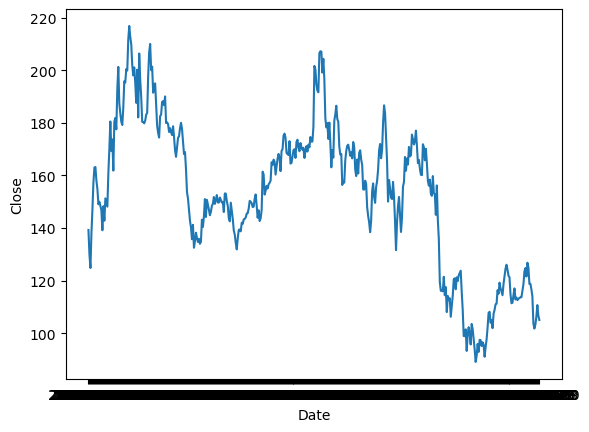

In [6]:
# seaborn
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb)

<Axes: xlabel='Date', ylabel='Close'>

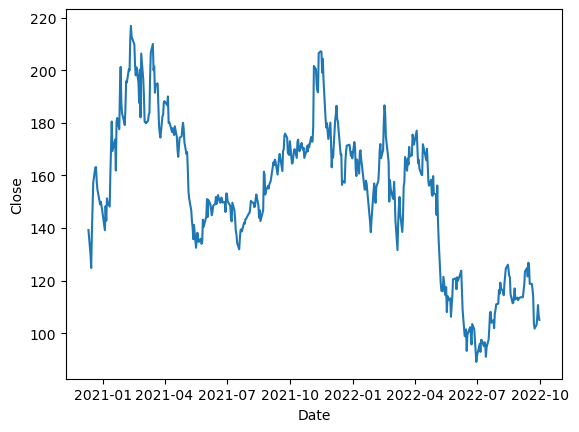

In [7]:
# datetime type 으로 변환
df_abnb['Date'] = pd.to_datetime(df_abnb['Date'])
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb)

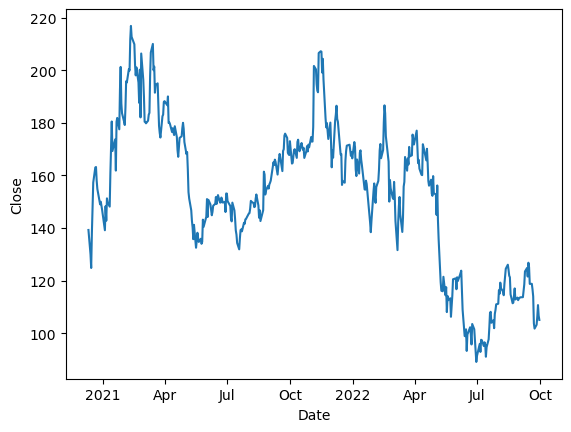

In [8]:
# 축레벨 회전, 표현방식을 변경 > fomatter를 사용
import matplotlib as mpl
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Close', data=df_abnb, ax=ax)
ax.xaxis.set_major_formatter(mpl.dates.ConciseDateFormatter(ax.xaxis.get_major_formatter()))

In [ ]:
# plotly line
px.line(df_abnb, x='Date', y='Close',width=500, height=400 )

In [11]:
fig = px.line(df_abnb, x='Date', y='Close',width=500, height=400 )
fig.update_xaxes(tickformat='%Y-%m-%d')

# 다중축 차트
- 기본차트 x,y + y1,y2 -> 하나의 ax에 그리기

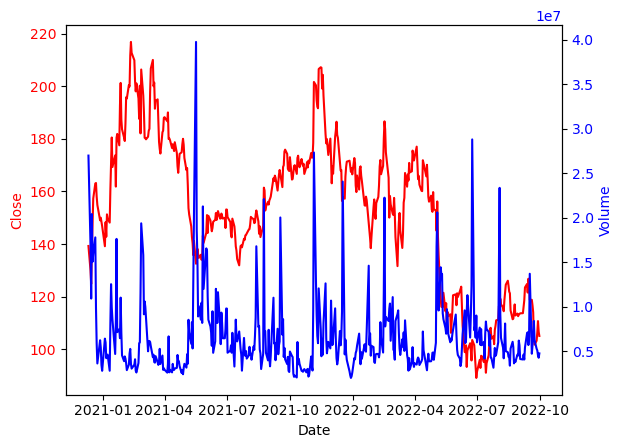

In [19]:
fig,ax = plt.subplots()
ax2=ax.twinx()

sns.lineplot( df_abnb,x='Date', y='Close', ax=ax, color='red')
sns.lineplot( df_abnb,x='Date', y='Volume',  ax=ax2, color='blue')

# 왼쪽 y축에 정보 설정
ax.tick_params(axis='y', labelcolor='red')
ax.yaxis.label.set_color('red')
# 오른쪽 y축에 정보 설정
ax2.tick_params(axis='y', labelcolor='blue')
ax2.yaxis.label.set_color('blue')

# x축 날짜 포맷 지정하기


In [ ]:
# 3개 축
# 최고가 - 최저가 - High_low 변수 추가
df_abnb['High-Low']=df_abnb['High']-df_abnb['Low']
df_abnb.head(1)

,Date,Open,High,Low,Close,Adj Close,Volume,High-Low
0,2020-12-11,146.550003,151.5,135.100006,139.25,139.25,26980800,16.399994


<Axes: xlabel='Date', ylabel='High-Low'>

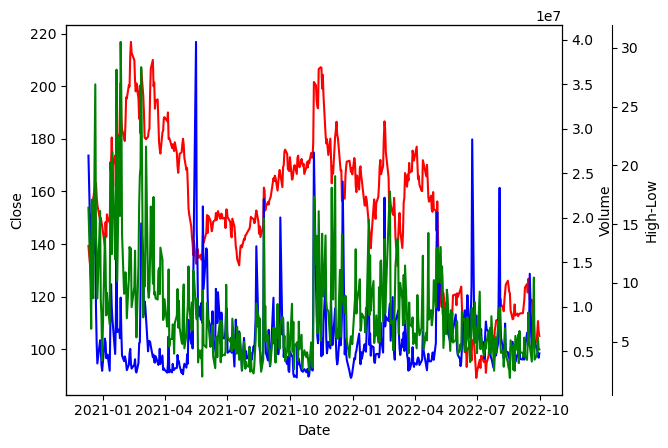

In [23]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax3 = ax.twinx()

ax3.spines.right.set_position(('axes', 1.1)) # 1.2만큼 오른쪽으로 이동

sns.lineplot( df_abnb,x='Date', y='Close', ax=ax, color='red')
sns.lineplot( df_abnb,x='Date', y='Volume',  ax=ax2, color='blue')
sns.lineplot( df_abnb,x='Date', y='High-Low',  ax=ax3, color='green')

In [29]:
# plotly 로 2중축 차트
from plotly.subplots import make_subplots
fig = make_subplots(specs=[[{"secondary_y": True}]]) # 2차원 리스트로 spec지정

# 축 설정
sub_fig1 = px.line(df_abnb, x='Date', y='Close')
sub_fig1.update_traces(line_color='red')
sub_fig2 = px.line(df_abnb, x='Date', y='Volume')
sub_fig2.update_traces(line_color='blue')

sub_fig2.update_traces(yaxis='y2')
fig.add_traces(sub_fig1.data + sub_fig2.data)

# 레이블 설정
fig.layout.xaxis.title = 'Date'
fig.layout.yaxis.title = 'Close'
fig.layout.yaxis.color = 'red'
fig.layout.yaxis2.title = 'Volume'
fig.layout.yaxis2.color = 'blue'

fig.update_layout(width=500, height= 400)


In [ ]:
# 강조하기


In [3]:
# 조건을 이용한 강조하기

In [4]:
# 기하급수적으로 증가하는 y축 값을 변환하여 표현

In [ ]:
# 색상 선택하기